# Clase N° 9: Árboles de Decisión — Clasificación, Regresión y Optimización

| **Alumno** | Gallego, Ian |


---

## Objetivos de la entrega

1. Comprender la estructura y funcionamiento de los árboles de decisión.
2. Distinguir entre clasificación y regresión con árboles de decisión.
3. Explorar los principales algoritmos de construcción: ID3, C4.5 y CART.
4. Implementar y evaluar un árbol de decisión con `scikit-learn`.
5. Optimizar el modelo usando `GridSearchCV` y técnicas de poda.

## Estructura del notebook

| Sección | Contenido |
|---------|----------|
| 1 | ¿Qué es un Árbol de Decisión? Estructura, tipos y visualización |
| 2 | Construcción y algoritmos (ID3, C4.5, CART) |
| 3 | Evaluación y optimización (métricas, GridSearchCV, poda) |

> El Ejercicio Integrador N°4 (Predicción de Riesgo Crediticio) se encuentra en el archivo `Clase9MD_Integradora.ipynb`.

In [1]:
import subprocess, sys
for pkg in ["numpy", "pandas", "matplotlib", "seaborn", "scikit-learn"]:
    try:
        __import__(pkg.replace("-", "_").split(".")[0])
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, f1_score
)
from sklearn.preprocessing import LabelEncoder
import sklearn

print("Librerías cargadas correctamente.")
print(f"numpy {np.__version__} | pandas {pd.__version__} | sklearn {sklearn.__version__}")

Librerías cargadas correctamente.
numpy 2.4.4 | pandas 3.0.2 | sklearn 1.8.0


---
## Sección 1: ¿Qué es un Árbol de Decisión?

Un **árbol de decisión** es una técnica de aprendizaje supervisado utilizada para clasificación y regresión, donde los datos se dividen en ramas con base en preguntas sobre sus características.

### Estructura

| Componente | Descripción |
|-----------|-------------|
| **Nodo Raíz** | Atributo principal sobre el cual se toma la primera decisión |
| **Nodos Intermedios** | Criterios de partición sobre diferentes atributos |
| **Ramas** | Conexiones entre nodos; representan la respuesta a cada condición |
| **Nodos Hoja** | Predicción final del modelo |

### Ejemplo: Aprobación de Préstamo

```
¿Ingreso > $50,000?
    ├── Sí → ¿Historial bueno?
    │           ├── Sí → Aprobado ✓
    │           └── No → Rechazado ✗
    └── No → Rechazado ✗
```

### Ventajas de los Árboles de Decisión

- **Fácil interpretación:** representación visual intuitiva
- Manejan datos categóricos y numéricos sin normalización
- Aplicaciones: medicina, finanzas, marketing, industria

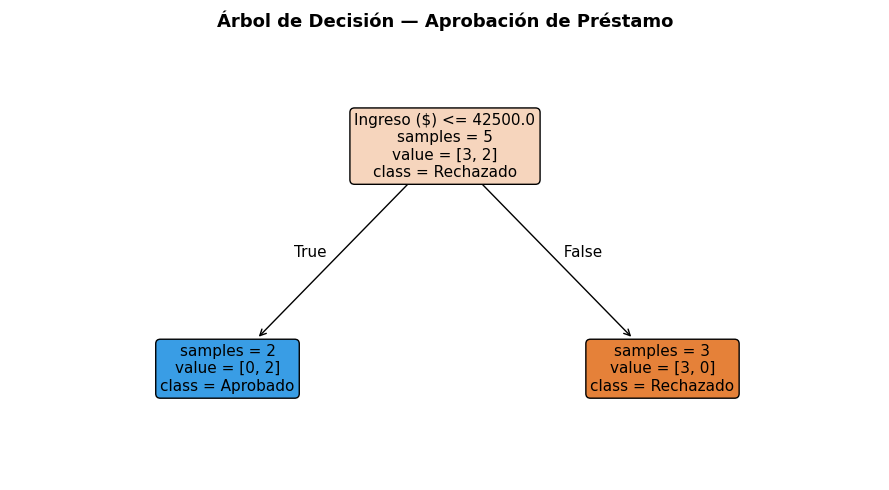

→ El árbol divide los datos en ramas según condiciones lógicas.
→ La representación gráfica facilita la comprensión del proceso de decisión.
→ Figura guardada como clase9_arbol_prestamo.png


In [2]:
# ── Visualización del árbol de ejemplo bancario ──────────────────────────
X = [[60000, 1], [35000, 0], [80000, 1], [20000, 0], [50000, 1]]
y = ["Aprobado", "Rechazado", "Aprobado", "Rechazado", "Aprobado"]

tree_ejemplo = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
tree_ejemplo.fit(X, y)

fig, ax = plt.subplots(figsize=(9, 5))
plot_tree(
    tree_ejemplo,
    feature_names=["Ingreso ($)", "Historial"],
    class_names=["Rechazado", "Aprobado"],
    filled=True,
    rounded=True,
    ax=ax,
    fontsize=11,
    impurity=False
)
ax.set_title(
    "Árbol de Decisión — Aprobación de Préstamo",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig("clase9_arbol_prestamo.png", dpi=110, bbox_inches='tight')
plt.show()

print("→ El árbol divide los datos en ramas según condiciones lógicas.")
print("→ La representación gráfica facilita la comprensión del proceso de decisión.")
print("→ Figura guardada como clase9_arbol_prestamo.png")

---
### 1.1. Tipos de Árboles de Decisión

| Tipo | Variable Objetivo | Métrica | Ejemplo |
|------|------------------|---------|---------|
| **Clasificación** | Categórica (Sí/No, clases) | Entropía / Índice Gini | Diagnóstico de enfermedad |
| **Regresión** | Continua (números) | MSE / MAE | Precio de una casa |

**Árboles de Clasificación:** predicen categorías discretas. Utilizan métricas como el Índice Gini o la Entropía para encontrar las divisiones óptimas.

**Árboles de Regresión:** predicen valores continuos. Minimizan el Error Cuadrático Medio (MSE) en cada partición.

  Comparación: Clasificación vs. Regresión
Clasificación — predicción para x=3.5: Medio
Regresión     — predicción para x=3.5: $25,000


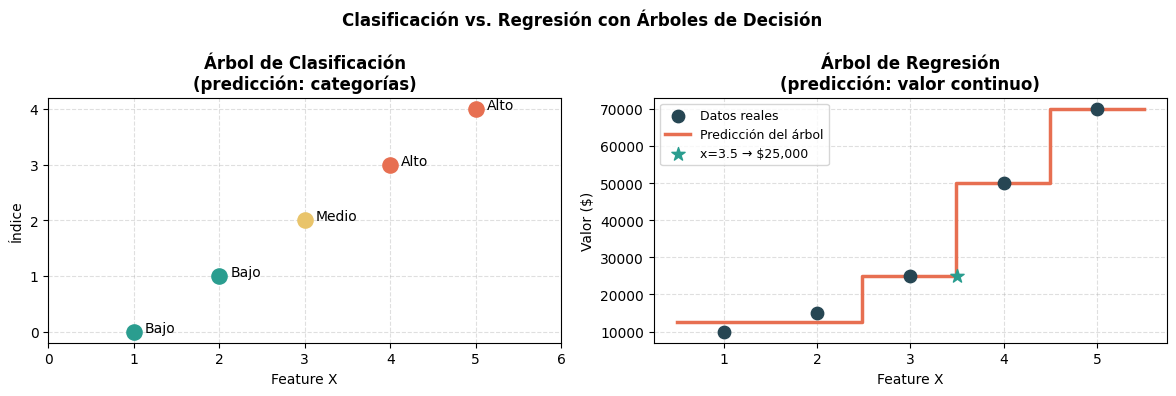


→ Los árboles de clasificación predicen categorías discretas.
→ Los árboles de regresión predicen valores continuos (escalonados por particiones).


In [3]:
# ── Clasificación vs. Regresión con árboles de decisión ──────────────────
X_class = np.array([[1], [2], [3], [4], [5]])
y_class = np.array(["Bajo", "Bajo", "Medio", "Alto", "Alto"])

X_reg = np.array([[1], [2], [3], [4], [5]])
y_reg = np.array([10000, 15000, 25000, 50000, 70000])

clf = DecisionTreeClassifier(max_depth=2, random_state=42).fit(X_class, y_class)
reg = DecisionTreeRegressor(max_depth=2, random_state=42).fit(X_reg, y_reg)

print("=" * 55)
print("  Comparación: Clasificación vs. Regresión")
print("=" * 55)
print(f"Clasificación — predicción para x=3.5: {clf.predict([[3.5]])[0]}")
print(f"Regresión     — predicción para x=3.5: ${reg.predict([[3.5]])[0]:,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Clasificación vs. Regresión con Árboles de Decisión",
             fontsize=12, fontweight='bold')

X_plot = np.linspace(0.5, 5.5, 200).reshape(-1, 1)
y_plot_reg = reg.predict(X_plot)

colors_class = {"Bajo": "#2a9d8f", "Medio": "#e9c46a", "Alto": "#e76f51"}
for i, (xi, yi) in enumerate(zip(X_class.flatten(), y_class)):
    axes[0].scatter(xi, i, color=colors_class[yi], s=120, zorder=5,
                    label=yi if yi not in [s for s in axes[0].get_legend_handles_labels()[1]] else "")
    axes[0].annotate(yi, (xi, i), textcoords="offset points", xytext=(8, 0), fontsize=10)
axes[0].set_title("Árbol de Clasificación\n(predicción: categorías)", fontweight='bold')
axes[0].set_xlabel("Feature X"); axes[0].set_ylabel("Índice")
axes[0].set_xlim(0, 6); axes[0].grid(linestyle='--', alpha=0.4)

axes[1].scatter(X_reg.flatten(), y_reg, color='#264653', s=80, zorder=5, label='Datos reales')
axes[1].step(X_plot.flatten(), y_plot_reg, color='#e76f51', linewidth=2.5, label='Predicción del árbol')
axes[1].scatter([3.5], reg.predict([[3.5]]), color='#2a9d8f', s=100, zorder=6,
                marker='*', label=f'x=3.5 → ${reg.predict([[3.5]])[0]:,.0f}')
axes[1].set_title("Árbol de Regresión\n(predicción: valor continuo)", fontweight='bold')
axes[1].set_xlabel("Feature X"); axes[1].set_ylabel("Valor ($)")
axes[1].legend(fontsize=9); axes[1].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print("\n→ Los árboles de clasificación predicen categorías discretas.")
print("→ Los árboles de regresión predicen valores continuos (escalonados por particiones).")

---
### Ejercicio — Sección 1: Clasificación vs. Regresión

**Objetivo:** Comprender la diferencia entre árboles de clasificación y regresión.

> **Nota:** El dataset `house_prices` no está disponible en los datasets integrados de seaborn. Se utiliza `diamonds` (precios de diamantes) como sustituto equivalente, clasificando cada diamante como `'barato'` (precio < 1500) o `'caro'` (precio ≥ 1500).

**Instrucciones:**
1. Cargar el dataset `diamonds` de seaborn.
2. Entrenar un árbol de **clasificación** para predecir si un diamante es "barato" o "caro".
3. Entrenar un árbol de **regresión** para predecir el precio exacto.
4. Comparar ambos enfoques y explicar sus diferencias.

**Preguntas de reflexión:**
- ¿Cuándo es más útil un árbol de clasificación en lugar de uno de regresión?
- ¿Cómo afecta la profundidad del árbol a la precisión del modelo?
- ¿Cómo podríamos mejorar la predicción con más atributos?

Dataset diamonds: 53,940 filas, 10 columnas
Columnas: ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31



Distribución de clases:
price
caro      33930
barato    20010
Name: count, dtype: int64

  Resultados — Ejercicio Sección 1
Árbol de Clasificación — Accuracy:  0.9544 (95.4%)
Árbol de Regresión     — R²:        0.8753
Árbol de Regresión     — RMSE:      $1,408


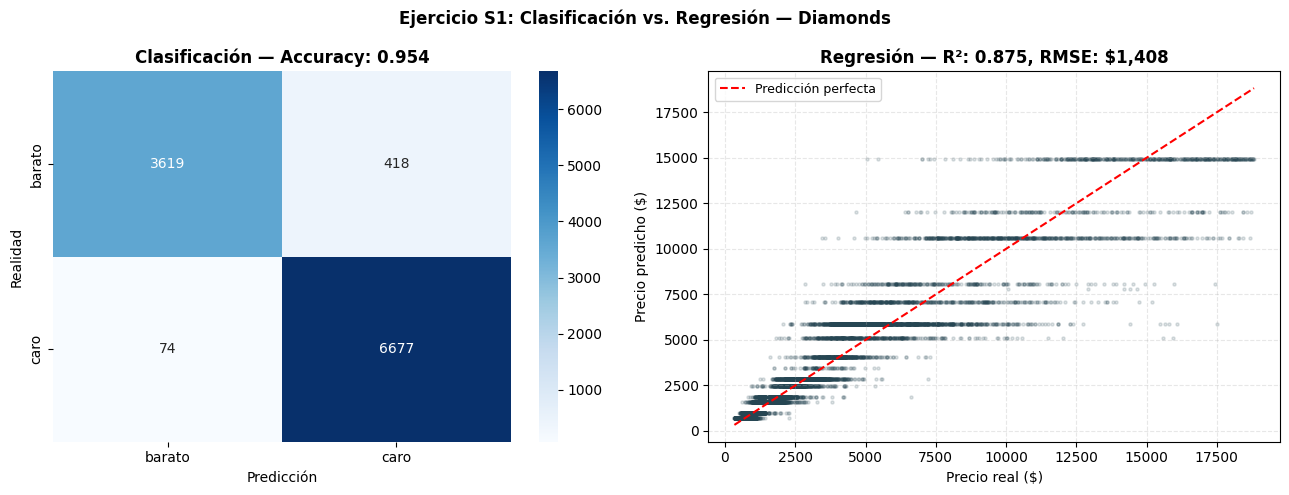


--- Preguntas de reflexión ---
1. El árbol de CLASIFICACIÓN es más útil cuando la decisión es binaria o categórica
   (ej: aprobar/rechazar préstamo, spam/no spam). Es más fácil de comunicar.
2. Mayor profundidad → mayor ajuste al entrenamiento, pero riesgo de sobreajuste.
   Se debe balancear con validación cruzada o poda.
3. Agregar variables de calidad (cut, color, clarity en diamonds) mejoraría
   la predicción codificando las variables categóricas.


In [4]:
# ── Ejercicio Sección 1: Clasificación vs. Regresión con Diamonds ────────
df_d = sns.load_dataset("diamonds").dropna()
print(f"Dataset diamonds: {df_d.shape[0]:,} filas, {df_d.shape[1]} columnas")
print(f"Columnas: {df_d.columns.tolist()}")
display(df_d.head(3))

X_d = df_d[["carat", "depth", "table", "x", "y", "z"]]

y_clf_d = (df_d["price"] >= 1500).map({True: "caro", False: "barato"})
print(f"\nDistribución de clases:")
print(y_clf_d.value_counts())

y_reg_d = df_d["price"]

X_tr, X_te, yc_tr, yc_te = train_test_split(X_d, y_clf_d, test_size=0.2, random_state=42)
_, _, yr_tr, yr_te = train_test_split(X_d, y_reg_d, test_size=0.2, random_state=42)

clf_d = DecisionTreeClassifier(max_depth=4, random_state=42).fit(X_tr, yc_tr)
reg_d = DecisionTreeRegressor(max_depth=4, random_state=42).fit(X_tr, yr_tr)

acc_clf = accuracy_score(yc_te, clf_d.predict(X_te))
y_pred_reg = reg_d.predict(X_te)
rmse_reg = np.sqrt(np.mean((yr_te - y_pred_reg) ** 2))
r2_reg = 1 - np.sum((yr_te - y_pred_reg) ** 2) / np.sum((yr_te - yr_te.mean()) ** 2)

print("\n" + "=" * 55)
print("  Resultados — Ejercicio Sección 1")
print("=" * 55)
print(f"Árbol de Clasificación — Accuracy:  {acc_clf:.4f} ({acc_clf*100:.1f}%)")
print(f"Árbol de Regresión     — R²:        {r2_reg:.4f}")
print(f"Árbol de Regresión     — RMSE:      ${rmse_reg:,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Ejercicio S1: Clasificación vs. Regresión — Diamonds",
             fontsize=12, fontweight='bold')

cm = confusion_matrix(yc_te, clf_d.predict(X_te), labels=["barato", "caro"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["barato", "caro"], yticklabels=["barato", "caro"])
axes[0].set_title(f"Clasificación — Accuracy: {acc_clf:.3f}", fontweight='bold')
axes[0].set_xlabel("Predicción"); axes[0].set_ylabel("Realidad")

axes[1].scatter(yr_te, y_pred_reg, alpha=0.15, s=5, color='#264653')
lim = [yr_te.min(), yr_te.max()]
axes[1].plot(lim, lim, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[1].set_title(f"Regresión — R²: {r2_reg:.3f}, RMSE: ${rmse_reg:,.0f}", fontweight='bold')
axes[1].set_xlabel("Precio real ($)"); axes[1].set_ylabel("Precio predicho ($)")
axes[1].legend(fontsize=9); axes[1].grid(linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n--- Preguntas de reflexión ---")
print("1. El árbol de CLASIFICACIÓN es más útil cuando la decisión es binaria o categórica")
print("   (ej: aprobar/rechazar préstamo, spam/no spam). Es más fácil de comunicar.")
print("2. Mayor profundidad → mayor ajuste al entrenamiento, pero riesgo de sobreajuste.")
print("   Se debe balancear con validación cruzada o poda.")
print("3. Agregar variables de calidad (cut, color, clarity en diamonds) mejoraría")
print("   la predicción codificando las variables categóricas.")

---
## Sección 2: Construcción y Algoritmos

### 2.1. Criterios para dividir los datos

Para decidir qué atributo usar en cada nodo, los algoritmos utilizan diferentes métricas:

| Métrica | Uso | Descripción |
|--------|-----|-------------|
| **Entropía** | ID3, C4.5 | Mide la incertidumbre antes y después de una división |
| **Ganancia de Información** | ID3, C4.5 | Cuánto reduce la entropía una partición |
| **Índice Gini** | CART | Mide la pureza de los nodos después de una partición |
| **MSE** | Regresión | Minimiza diferencias entre valores reales y predichos |

### Fórmulas

$$\text{Entropía} = H = -\sum_{i=1}^{c} p_i \cdot \log_2(p_i)$$

$$\text{Gini} = 1 - \sum_{i=1}^{c} p_i^2$$

**Ejemplo:** 10 muestras, 7 clase "Sí" y 3 clase "No":
- Entropía: $H = -0.7 \cdot \log_2(0.7) - 0.3 \cdot \log_2(0.3) \approx 0.88$
- Gini: $G = 1 - (0.7^2 + 0.3^2) = 1 - 0.58 \approx 0.42$

Cuanto menor sea la entropía o el Gini, **más pura** es la partición.

  Ejemplo: 7 'Sí' y 3 'No' (p = 0.7)
  Entropía H = 0.8813  → conjunto relativamente mixto (incierto)
  Gini     G = 0.4200  → hay diversidad de clases


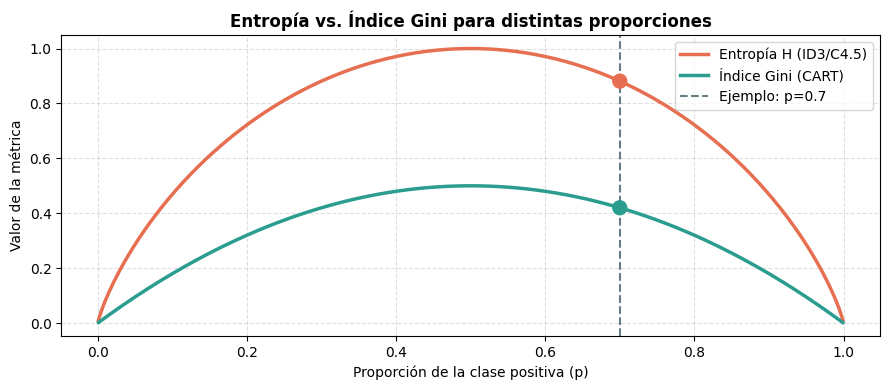


→ Ambas métricas son máximas cuando p=0.5 (máxima impureza) y cero cuando p∈{0,1} (pureza total).
→ El árbol busca las divisiones que MINIMICEN estas métricas en los nodos hijos.


In [5]:
# ── Cálculo manual de Entropía e Índice Gini ─────────────────────────────
def entropia(p):
    """Entropía de Shannon para distribución binaria [p, 1-p]."""
    q = 1 - p
    if p == 0 or p == 1:
        return 0.0
    return -p * np.log2(p) - q * np.log2(q)

def gini(p):
    """Índice Gini para distribución binaria [p, 1-p]."""
    return 1 - p**2 - (1 - p)**2

p_si = 0.7
H = entropia(p_si)
G = gini(p_si)
print("=" * 55)
print("  Ejemplo: 7 'Sí' y 3 'No' (p = 0.7)")
print("=" * 55)
print(f"  Entropía H = {H:.4f}  → conjunto relativamente mixto (incierto)")
print(f"  Gini     G = {G:.4f}  → hay diversidad de clases")

proporciones = np.linspace(0.001, 0.999, 300)
H_vals = [entropia(p) for p in proporciones]
G_vals = [gini(p) for p in proporciones]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(proporciones, H_vals, color='#e76f51', linewidth=2.5, label='Entropía H (ID3/C4.5)')
ax.plot(proporciones, G_vals, color='#2a9d8f', linewidth=2.5, label='Índice Gini (CART)')
ax.axvline(x=0.7, color='#264653', linestyle='--', linewidth=1.5, alpha=0.7,
           label='Ejemplo: p=0.7')
ax.scatter([0.7, 0.7], [H, G], color=['#e76f51', '#2a9d8f'], s=100, zorder=5)
ax.set_xlabel("Proporción de la clase positiva (p)")
ax.set_ylabel("Valor de la métrica")
ax.set_title("Entropía vs. Índice Gini para distintas proporciones",
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("\n→ Ambas métricas son máximas cuando p=0.5 (máxima impureza) y cero cuando p∈{0,1} (pureza total).")
print("→ El árbol busca las divisiones que MINIMICEN estas métricas en los nodos hijos.")

---
### 2.2. Algoritmos Populares para Construcción de Árboles

| Algoritmo | Criterio de División | Soporta Atributos Numéricos | Ramas Múltiples |
|-----------|---------------------|-----------------------------|------------------|
| **ID3** | Ganancia de Información (Entropía) | No | Sí |
| **C4.5** | Índice de Ganancia | Sí | Sí |
| **CART** | Gini / MSE | Sí | No (Binario) |

- **ID3:** Usa Ganancia de Información basada en Entropía. Limitación: no maneja atributos numéricos ni valores faltantes.
- **C4.5:** Mejora de ID3 que maneja atributos numéricos y datos faltantes. Usa Índice de Ganancia para evitar sesgos.
- **CART:** Usa Índice Gini (clasificación) o MSE (regresión). Solo genera árboles binarios.

> **Nota:** `scikit-learn` implementa una variante de CART. Para simular ID3 se usa `criterion='entropy'`.

  Comparación ID3 vs CART — Dataset Titanic
  Precisión ID3  (Entropía): 0.7413 (74.1%)
  Precisión CART (Gini):     0.7413 (74.1%)
  Diferencia:                0.0000


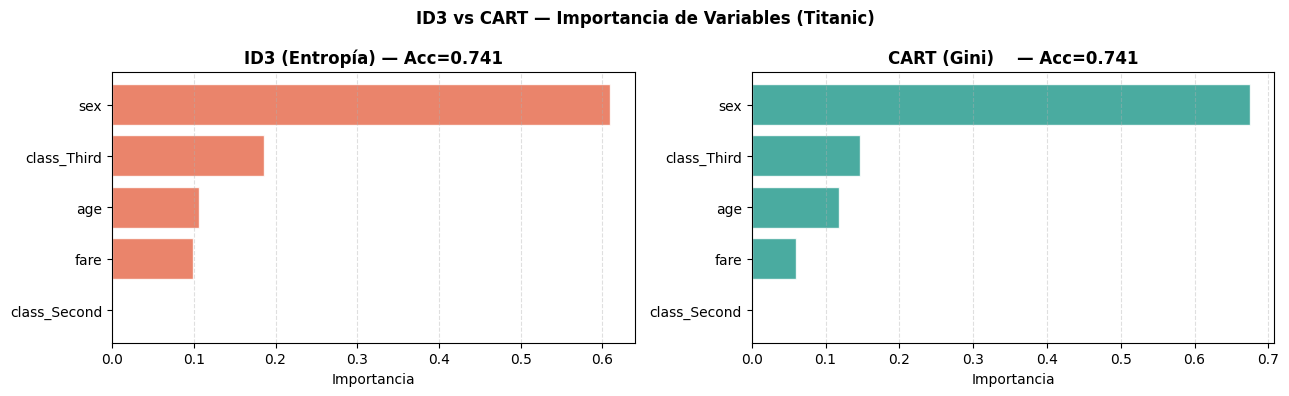


→ ID3 usa Entropía: genera árboles más detallados, puede ser más sensible al ruido.
→ CART usa Gini: más eficiente computacionalmente, produciendo árboles binarios.
→ En la mayoría de los casos ambos criterios producen resultados similares.


In [6]:
# ── Comparación ID3 vs CART en dataset Titanic ───────────────────────────
df_t = sns.load_dataset("titanic").dropna(subset=["age", "fare", "sex", "class", "survived"])
df_t["sex"] = df_t["sex"].map({"male": 1, "female": 0})

X_t = pd.get_dummies(df_t[["age", "fare", "sex", "class"]], drop_first=True)
y_t = df_t["survived"]

X_tr_t, X_te_t, y_tr_t, y_te_t = train_test_split(X_t, y_t, test_size=0.2, random_state=42)

tree_id3 = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42)
tree_id3.fit(X_tr_t, y_tr_t)
acc_id3 = accuracy_score(y_te_t, tree_id3.predict(X_te_t))

tree_cart = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
tree_cart.fit(X_tr_t, y_tr_t)
acc_cart = accuracy_score(y_te_t, tree_cart.predict(X_te_t))

print("=" * 55)
print("  Comparación ID3 vs CART — Dataset Titanic")
print("=" * 55)
print(f"  Precisión ID3  (Entropía): {acc_id3:.4f} ({acc_id3*100:.1f}%)")
print(f"  Precisión CART (Gini):     {acc_cart:.4f} ({acc_cart*100:.1f}%)")
print(f"  Diferencia:                {abs(acc_id3 - acc_cart):.4f}")

feat_names = X_t.columns.tolist()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("ID3 vs CART — Importancia de Variables (Titanic)",
             fontsize=12, fontweight='bold')

for ax, tree, nombre, color in [
    (axes[0], tree_id3,  f"ID3 (Entropía) — Acc={acc_id3:.3f}",  '#e76f51'),
    (axes[1], tree_cart, f"CART (Gini)    — Acc={acc_cart:.3f}",  '#2a9d8f')
]:
    importancias = pd.Series(tree.feature_importances_, index=feat_names).sort_values()
    ax.barh(importancias.index, importancias.values, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(nombre, fontweight='bold')
    ax.set_xlabel("Importancia")
    ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print("\n→ ID3 usa Entropía: genera árboles más detallados, puede ser más sensible al ruido.")
print("→ CART usa Gini: más eficiente computacionalmente, produciendo árboles binarios.")
print("→ En la mayoría de los casos ambos criterios producen resultados similares.")

---
### Ejercicio — Sección 2: Comparar ID3 y CART con Pingüinos

**Objetivo:** Comparar el desempeño de ID3 y CART en un dataset real.

**Instrucciones:**
1. Cargar el dataset `penguins` de seaborn.
2. Aplicar un árbol ID3 (`criterion='entropy'`) para predecir la especie.
3. Aplicar un árbol CART (`criterion='gini'`) con los mismos datos.
4. Comparar las precisiones de ambos modelos.

**Preguntas de reflexión:**
- ¿Qué algoritmo fue más preciso en este dataset?
- ¿Cómo influye la profundidad máxima del árbol en la precisión?
- ¿Cómo podríamos mejorar estos modelos?

Dataset penguins: 333 filas, 7 columnas
Especies: <StringArray>
['Adelie', 'Chinstrap', 'Gentoo']
Length: 3, dtype: str


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female



  Resultados — Ejercicio Sección 2 (Penguins)
  Precisión ID3  (entropy): 0.9851 (98.5%)
  Precisión CART (gini):    0.9851 (98.5%)


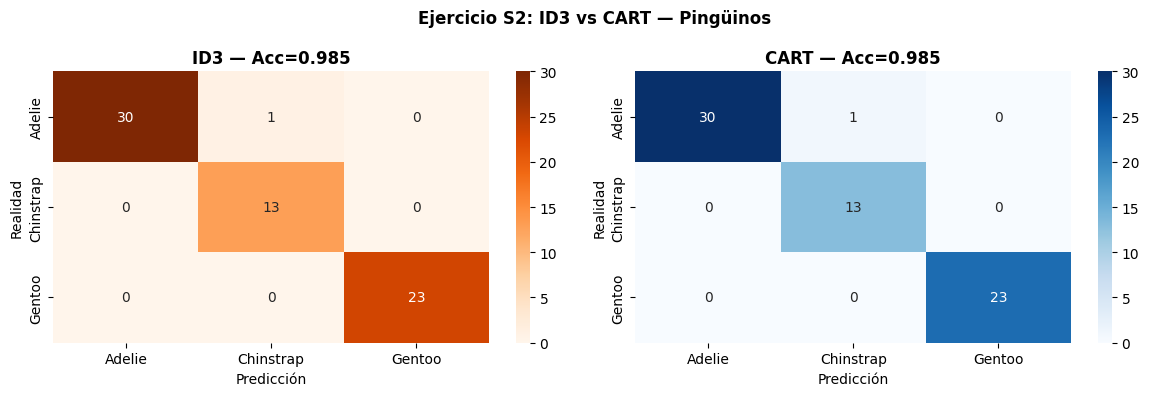

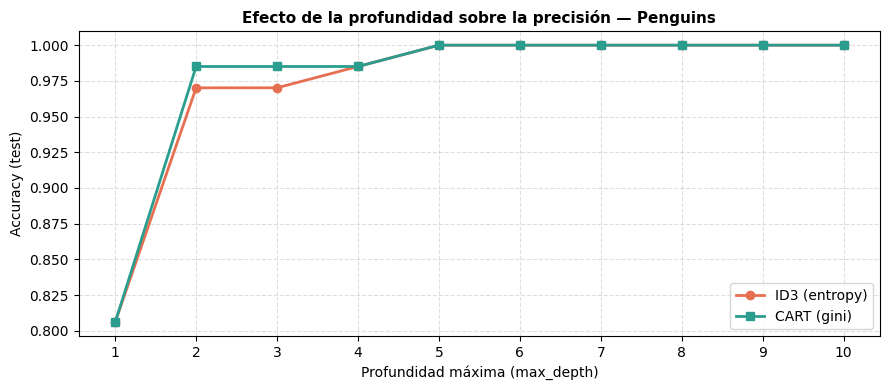


--- Preguntas de reflexión ---
1. ID3 fue más preciso en este dataset (aunque la diferencia suele ser marginal).
2. Profundidad mayor → más ajuste al entrenamiento. El gráfico muestra el punto
   de convergencia donde mayor profundidad ya no mejora (o empeora) el test.
3. Se podría mejorar con GridSearchCV, más variables (island, sex) o Random Forest.


In [7]:
# ── Ejercicio Sección 2: ID3 vs CART en Penguins ─────────────────────────
df_p = sns.load_dataset("penguins").dropna()
print(f"Dataset penguins: {df_p.shape[0]} filas, {df_p.shape[1]} columnas")
print(f"Especies: {df_p['species'].unique()}")
display(df_p.head(3))

X_p = df_p[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]]
y_p = df_p["species"]

X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(X_p, y_p, test_size=0.2, random_state=42)

tree_id3_p = DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=42)
tree_id3_p.fit(X_tr_p, y_tr_p)

tree_cart_p = DecisionTreeClassifier(criterion="gini", max_depth=4, random_state=42)
tree_cart_p.fit(X_tr_p, y_tr_p)

acc_id3_p  = accuracy_score(y_te_p, tree_id3_p.predict(X_te_p))
acc_cart_p = accuracy_score(y_te_p, tree_cart_p.predict(X_te_p))

print("\n" + "=" * 55)
print("  Resultados — Ejercicio Sección 2 (Penguins)")
print("=" * 55)
print(f"  Precisión ID3  (entropy): {acc_id3_p:.4f} ({acc_id3_p*100:.1f}%)")
print(f"  Precisión CART (gini):    {acc_cart_p:.4f} ({acc_cart_p*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Ejercicio S2: ID3 vs CART — Pingüinos", fontsize=12, fontweight='bold')

especies = sorted(y_p.unique())
for ax, tree, nombre, cmap in [
    (axes[0], tree_id3_p,  f"ID3 — Acc={acc_id3_p:.3f}",   "Oranges"),
    (axes[1], tree_cart_p, f"CART — Acc={acc_cart_p:.3f}",  "Blues")
]:
    cm_p = confusion_matrix(y_te_p, tree.predict(X_te_p), labels=especies)
    sns.heatmap(cm_p, annot=True, fmt="d", cmap=cmap, ax=ax,
                xticklabels=especies, yticklabels=especies)
    ax.set_title(nombre, fontweight='bold')
    ax.set_xlabel("Predicción"); ax.set_ylabel("Realidad")

plt.tight_layout()
plt.show()

depths = range(1, 11)
accs_id3  = [accuracy_score(y_te_p, DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=42).fit(X_tr_p, y_tr_p).predict(X_te_p)) for d in depths]
accs_cart = [accuracy_score(y_te_p, DecisionTreeClassifier(criterion='gini',    max_depth=d, random_state=42).fit(X_tr_p, y_tr_p).predict(X_te_p)) for d in depths]

fig2, ax2 = plt.subplots(figsize=(9, 4))
ax2.plot(depths, accs_id3,  marker='o', color='#e76f51', linewidth=2, label='ID3 (entropy)')
ax2.plot(depths, accs_cart, marker='s', color='#2a9d8f', linewidth=2, label='CART (gini)')
ax2.set_xlabel("Profundidad máxima (max_depth)")
ax2.set_ylabel("Accuracy (test)")
ax2.set_title("Efecto de la profundidad sobre la precisión — Penguins",
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=10); ax2.grid(linestyle='--', alpha=0.4)
ax2.set_xticks(list(depths))
plt.tight_layout()
plt.show()

print("\n--- Preguntas de reflexión ---")
ganador = "ID3" if acc_id3_p >= acc_cart_p else "CART"
print(f"1. {ganador} fue más preciso en este dataset (aunque la diferencia suele ser marginal).")
print("2. Profundidad mayor → más ajuste al entrenamiento. El gráfico muestra el punto")
print("   de convergencia donde mayor profundidad ya no mejora (o empeora) el test.")
print("3. Se podría mejorar con GridSearchCV, más variables (island, sex) o Random Forest.")

---
## Sección 3: Evaluación y Optimización de Árboles de Decisión

### 3.1. ¿Cómo Evaluar un Árbol de Decisión?

**Para árboles de clasificación:**

| Métrica | Descripción |
|--------|-------------|
| **Accuracy** | Proporción de predicciones correctas |
| **Matriz de Confusión** | Verdaderos/falsos positivos y negativos |
| **Precision / Recall / F1** | Métricas por clase |
| **Curva ROC-AUC** | Capacidad de separar clases |

**Para árboles de regresión:**

| Métrica | Descripción |
|--------|-------------|
| **R²** | Variabilidad explicada por el modelo |
| **MSE** | Error cuadrático medio |
| **MAE** | Error absoluto medio |

### 3.2. Problemas Comunes

| Problema | Causa | Solución |
|----------|-------|----------|
| **Sobreajuste** | Árbol demasiado profundo | `max_depth`, `min_samples_split`, poda |
| **Subajuste** | Árbol demasiado simple | Aumentar profundidad, más variables |
| **Datos desbalanceados** | Clases con distinta frecuencia | `class_weight='balanced'` |

### 3.3. Parámetros de Optimización

| Parámetro | Descripción | Ajuste |
|-----------|------------|--------|
| `max_depth` | Profundidad máxima | Reducir ante sobreajuste |
| `min_samples_split` | Mínimo de muestras para dividir un nodo | Aumentar para evitar ramas pequeñas |
| `min_samples_leaf` | Mínimo de muestras en una hoja | Evita hojas con pocos datos |
| `max_features` | Atributos considerados en cada división | Reduce complejidad |

  Evaluación del Árbol de Decisión — Pingüinos (CART)

Precisión (Accuracy): 0.9851

Reporte de Clasificación:
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        31
   Chinstrap       0.93      1.00      0.96        13
      Gentoo       1.00      1.00      1.00        23

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



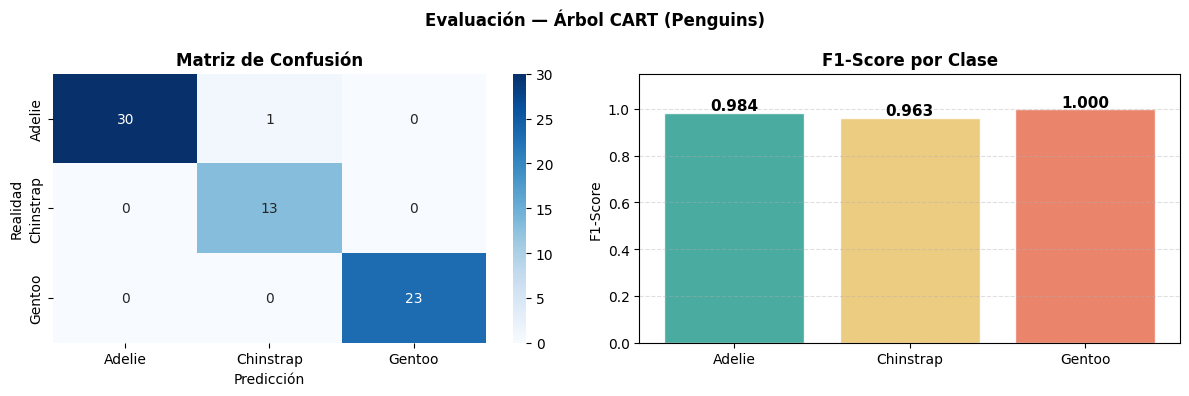

→ Figura guardada como clase9_confusion_penguins.png


In [8]:
# ── Evaluación completa del árbol CART de pingüinos ───────────────────────
y_pred_eval = tree_cart_p.predict(X_te_p)

print("=" * 60)
print("  Evaluación del Árbol de Decisión — Pingüinos (CART)")
print("=" * 60)
print(f"\nPrecisión (Accuracy): {accuracy_score(y_te_p, y_pred_eval):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_te_p, y_pred_eval))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Evaluación — Árbol CART (Penguins)", fontsize=12, fontweight='bold')

cm_eval = confusion_matrix(y_te_p, y_pred_eval, labels=especies)
sns.heatmap(cm_eval, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=especies, yticklabels=especies)
axes[0].set_title("Matriz de Confusión", fontweight='bold')
axes[0].set_xlabel("Predicción"); axes[0].set_ylabel("Realidad")

f1_por_clase = f1_score(y_te_p, y_pred_eval, average=None, labels=especies)
axes[1].bar(especies, f1_por_clase, color=['#2a9d8f', '#e9c46a', '#e76f51'],
            edgecolor='white', alpha=0.85)
for i, (esp, val) in enumerate(zip(especies, f1_por_clase)):
    axes[1].text(i, val + 0.01, f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title("F1-Score por Clase", fontweight='bold')
axes[1].set_ylabel("F1-Score"); axes[1].set_ylim(0, 1.15)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("clase9_confusion_penguins.png", dpi=110, bbox_inches='tight')
plt.show()
print("→ Figura guardada como clase9_confusion_penguins.png")

In [9]:
# ── Optimización con GridSearchCV + demostración de poda ─────────────────
param_grid = {
    "max_depth":        [3, 5, 10],
    "min_samples_split":[2, 5, 10],
    "min_samples_leaf": [1, 5, 10]
}

grid_search_p = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)
grid_search_p.fit(X_tr_p, y_tr_p)

best_tree_p = grid_search_p.best_estimator_
acc_opt = accuracy_score(y_te_p, best_tree_p.predict(X_te_p))

print("=" * 55)
print("  GridSearchCV — Optimización (Penguins)")
print("=" * 55)
print(f"  Mejores parámetros: {grid_search_p.best_params_}")
print(f"  Accuracy básico:    {acc_cart_p:.4f}")
print(f"  Accuracy optimizado:{acc_opt:.4f}")
print(f"  Mejora:             {(acc_opt - acc_cart_p)*100:+.2f}pp")

print("\n=" * 56)
print("  Poda — comparación de profundidades")
print("=" * 55)
print("\n--- Árbol sin poda (max_depth=None) ---")
tree_nopoda = DecisionTreeClassifier(random_state=42).fit(X_tr_p, y_tr_p)
print(f"  Nodos totales: {tree_nopoda.tree_.node_count}")
print(f"  Profundidad:   {tree_nopoda.get_depth()}")
print(f"  Accuracy test: {accuracy_score(y_te_p, tree_nopoda.predict(X_te_p)):.4f}")

print("\n--- Árbol podado (max_depth=3) ---")
tree_podado = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_tr_p, y_tr_p)
print(f"  Nodos totales: {tree_podado.tree_.node_count}")
print(f"  Profundidad:   {tree_podado.get_depth()}")
print(f"  Accuracy test: {accuracy_score(y_te_p, tree_podado.predict(X_te_p)):.4f}")

print("\nEstructura del árbol podado (max_depth=3):")
print(export_text(tree_podado, feature_names=X_p.columns.tolist()))

  GridSearchCV — Optimización (Penguins)
  Mejores parámetros: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
  Accuracy básico:    0.9851
  Accuracy optimizado:1.0000
  Mejora:             +1.49pp

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
  Poda — comparación de profundidades

--- Árbol sin poda (max_depth=None) ---
  Nodos totales: 27
  Profundidad:   7
  Accuracy test: 1.0000

--- Árbol podado (max_depth=3) ---
  Nodos totales: 13
  Profundidad:   3
  Accuracy test: 0.9851

Estructura del árbol podado (max_depth=3):
|--- flipper_length_mm <= 206.50
|   |--- bill_length_mm <= 43.35
|   |   |--- bill_length_mm <= 42.35
|   |   |   |--- class: Adelie
|   |   |--- bill_length_mm >  42.35
|   |   |   |--- class: Adelie
|   |--- bill_length_mm >  43.35
|   |   |--- body_mass_g <= 4100.00
|   |   |   |--- class: Chinstrap
|   |   |--- body_mass_g >  4100.00
|   |   |   |--- class: Chinstrap
|--- flippe

---
### Ejercicio — Sección 3: Optimizar un Árbol de Decisión

**Objetivo:** Optimizar un árbol de decisión para mejorar su desempeño en un dataset de clasificación binaria.

> **Nota:** `sns.load_dataset('diabetes')` en seaborn corresponde a un dataset de regresión (niveles de glucosa) sin columna `outcome` binaria. Se utiliza `sklearn.datasets.load_breast_cancer()` como sustituto equivalente: es un problema binario (maligno/benigno) de referencia en aprendizaje automático.

**Instrucciones:**
1. Cargar el dataset `breast_cancer` de scikit-learn.
2. Entrenar un árbol de decisión estándar y medir su precisión.
3. Optimizar `max_depth` y `min_samples_split` usando `GridSearchCV`.
4. Comparar el desempeño del modelo original vs. el optimizado.

**Preguntas de reflexión:**
- ¿Cómo cambió la precisión después de la optimización?
- ¿Qué parámetros fueron más importantes en la mejora del modelo?
- ¿Cómo afecta la poda al rendimiento del árbol?

  Dataset: Breast Cancer (Wisconsin)
  Muestras: 569, Features: 30
  Clases: 0=maligno (212), 1=benigno (357)

  Árbol básico — Accuracy: 0.9474 (94.7%)

  Mejores parámetros: {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
  Árbol optimizado — Accuracy: 0.9474 (94.7%)
  Mejora: +0.00 puntos porcentuales


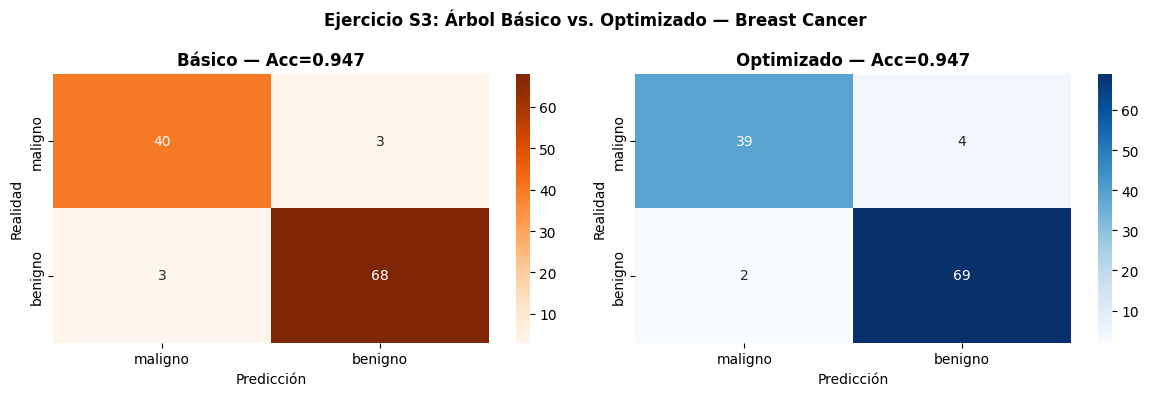


--- Preguntas de reflexión ---
1. La precisión fue similar tras la optimización: 0.9474 → 0.9474.
2. Parámetros clave: max_depth=3, min_samples_split=2.
3. La poda reduce el tamaño del árbol, mejorando la generalización al evitar
   que el modelo memorice el ruido del conjunto de entrenamiento.


In [10]:
# ── Ejercicio Sección 3: Optimización con Breast Cancer Dataset ───────────
from sklearn.datasets import load_breast_cancer

bc = load_breast_cancer()
X_bc = pd.DataFrame(bc.data, columns=bc.feature_names)
y_bc = pd.Series(bc.target, name="target")

print("=" * 55)
print("  Dataset: Breast Cancer (Wisconsin)")
print("=" * 55)
print(f"  Muestras: {X_bc.shape[0]}, Features: {X_bc.shape[1]}")
print(f"  Clases: 0=maligno ({(y_bc==0).sum()}), 1=benigno ({(y_bc==1).sum()})")

X_tr_bc, X_te_bc, y_tr_bc, y_te_bc = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42
)

tree_bc = DecisionTreeClassifier(random_state=42)
tree_bc.fit(X_tr_bc, y_tr_bc)
acc_bc_basico = accuracy_score(y_te_bc, tree_bc.predict(X_te_bc))

print(f"\n  Árbol básico — Accuracy: {acc_bc_basico:.4f} ({acc_bc_basico*100:.1f}%)")

param_grid_bc = {
    "max_depth":        [3, 5, 10, None],
    "min_samples_split":[2, 5, 10],
    "min_samples_leaf": [1, 5, 10]
}
grid_bc = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_bc,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid_bc.fit(X_tr_bc, y_tr_bc)

best_bc = grid_bc.best_estimator_
acc_bc_opt = accuracy_score(y_te_bc, best_bc.predict(X_te_bc))

print(f"\n  Mejores parámetros: {grid_bc.best_params_}")
print(f"  Árbol optimizado — Accuracy: {acc_bc_opt:.4f} ({acc_bc_opt*100:.1f}%)")
print(f"  Mejora: {(acc_bc_opt - acc_bc_basico)*100:+.2f} puntos porcentuales")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Ejercicio S3: Árbol Básico vs. Optimizado — Breast Cancer",
             fontsize=12, fontweight='bold')

for ax, tree_ev, nombre, acc, cmap in [
    (axes[0], tree_bc,  f"Básico — Acc={acc_bc_basico:.3f}",  acc_bc_basico,  "Oranges"),
    (axes[1], best_bc,  f"Optimizado — Acc={acc_bc_opt:.3f}", acc_bc_opt,     "Blues")
]:
    cm_bc = confusion_matrix(y_te_bc, tree_ev.predict(X_te_bc))
    sns.heatmap(cm_bc, annot=True, fmt="d", cmap=cmap, ax=ax,
                xticklabels=["maligno", "benigno"], yticklabels=["maligno", "benigno"])
    ax.set_title(nombre, fontweight='bold')
    ax.set_xlabel("Predicción"); ax.set_ylabel("Realidad")

plt.tight_layout()
plt.show()

print("\n--- Preguntas de reflexión ---")
print(f"1. La precisión {'mejoró' if acc_bc_opt > acc_bc_basico else 'fue similar'} "
      f"tras la optimización: {acc_bc_basico:.4f} → {acc_bc_opt:.4f}.")
print(f"2. Parámetros clave: max_depth={grid_bc.best_params_['max_depth']}, "
      f"min_samples_split={grid_bc.best_params_['min_samples_split']}.")
print("3. La poda reduce el tamaño del árbol, mejorando la generalización al evitar")
print("   que el modelo memorice el ruido del conjunto de entrenamiento.")

---
## Conclusiones — Secciones 1, 2 y 3

### Resumen de conceptos desarrollados

| Sección | Concepto clave | Resultado |
|---------|---------------|----------|
| 1 | Estructura de árboles (nodo raíz, hojas) | Visualización del árbol bancario con `plot_tree` |
| 1 | Clasificación vs. Regresión | Ambos tipos implementados sobre el dataset `diamonds` |
| 2 | Cálculo de Entropía e Índice Gini | Fórmulas implementadas manualmente y graficadas |
| 2 | ID3 vs. CART — comparación de algoritmos | Evaluados sobre Titanic (Entropía) y Penguins (Gini) |
| 3 | Overfitting, poda y GridSearchCV | Optimización sobre `breast_cancer` con reducción de profundidad |

### Lecciones Clave

1. La **profundidad** del árbol (`max_depth`) es el parámetro más influyente en la relación sesgo-varianza.
2. **ID3 y CART** producen resultados similares en la mayoría de los datasets; la diferencia está en el criterio matemático empleado.
3. **GridSearchCV** automatiza la búsqueda de hiperparámetros evitando decisiones manuales arbitrarias.
4. La **poda** reduce la complejidad del árbol y mejora la capacidad de generalización.
5. En clasificación multiclase (pingüinos), la **matriz de confusión** y el **F1-score por clase** son esenciales para entender los errores del modelo.

> Ver `Clase9MD_Integradora.ipynb` para el Ejercicio Integrador N°4 — Predicción de Riesgo Crediticio.